In [274]:
import numpy as np
import matplotlib.pyplot as plt
import brian2 as b2
from brian2 import ms, mV, nS
import opto_stim_model

opto_stim_model.set_style()

In [275]:
seed = 18300406
bin_size = 50 * ms  # time bin for all firing rate calculations

## **Single exponential LIF model**

---
Define model

In [276]:
b2.prefs.codegen.target = "numpy"
b2.defaultclock.dt = 0.05 * ms
b2.seed(seed)

n_neurons = 1

# Membrane parameters (conductance-based LIF)
C_m = 50 * b2.pfarad
g_L = 25 * nS
E_L = -70 * mV
E_opsin = 0 * mV  # ChR2 reversal potential
V_reset = -70 * mV
V_thresh = -45 * mV
refractory_period = 5 * ms

# Opsin parameters
w_opsin = 16.8 * nS    # Weight: max conductance at full expression
tau_decay = 15 * ms    # Decay time constant controls dynamics

# Define LIF equations
lif_eqs = b2.Equations(
    """
    dv/dt = (g_L*(E_L - v) + g_opsin * (E_opsin - v) + I_bg) / C_m : volt
    dg_opsin/dt = (w_opsin * stim_array(t) - g_opsin) / tau_decay : siemens
    I_bg : amp
    """,
    C_m=C_m,
    g_L=g_L,
    E_L=E_L,
    E_opsin=E_opsin,
    w_opsin=w_opsin,
    tau_decay=tau_decay,
)

---
Investigate spontaneous behaviour

In [277]:
# Create time array for simulation
simulation_period = 500 * ms
t_array = np.arange(0, simulation_period/ms, b2.defaultclock.dt/ms) * ms  # values in ms, then convert

In [278]:
b2.start_scope()
# Run simulation with no input to observe spontaneous behaviour
stim_array = b2.TimedArray(np.zeros(len(t_array)), dt=b2.defaultclock.dt)  # No input
neuron_group = b2.NeuronGroup(n_neurons, lif_eqs, threshold="v > V_thresh", reset="v = V_reset", method="euler", refractory=refractory_period)
neuron_group.v = E_L  # Start at resting potential
spike_monitor = b2.SpikeMonitor(neuron_group)
b2.run(simulation_period)

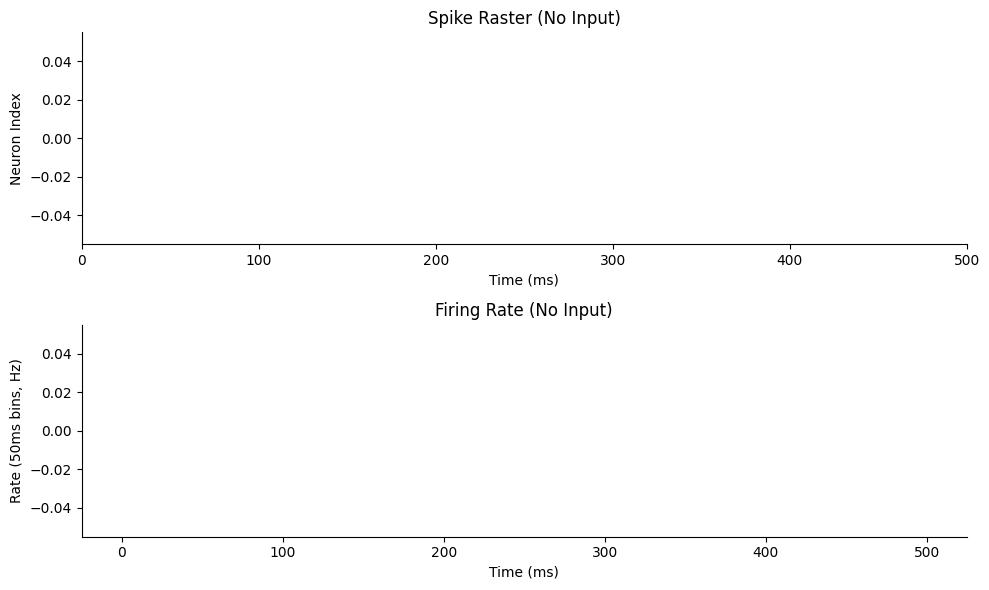

In [279]:
# Plot spike raster
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.title("Spike Raster (No Input)")
plt.plot(spike_monitor.t / ms, spike_monitor.i, "k.", markersize=2)
plt.xlabel("Time (ms)")
plt.ylabel("Neuron Index")
plt.xlim(0, simulation_period / ms)

plt.subplot(2, 1, 2)
plt.title("Firing Rate (No Input)")
rate, edges = np.histogram(spike_monitor.t / ms, bins=np.arange(0, simulation_period / ms + bin_size / ms, bin_size / ms))
plt.bar(edges[:-1], rate / (n_neurons * (bin_size / ms)), width=bin_size / ms, align="edge", color="gray")
plt.xlabel("Time (ms)")
plt.ylabel(f"Rate ({int(bin_size/ms)}ms bins, Hz)")

plt.show()

---
Direct current injection (no opsin)

In [280]:
# LIF equations with direct current input (no opsin)
lif_eqs_current = b2.Equations(
    """
    dv/dt = (g_L*(E_L - v) + I_ext(t) + I_bg) / C_m : volt
    I_bg : amp
    """,
    C_m=C_m,
    g_L=g_L,
    E_L=E_L,
)

# Threshold current = g_L * (V_thresh - E_L) = 25 nS * 25 mV = 625 pA
# ~800 pA represents ~20-40 synchronous AMPA synapses from excitatory V1 neurons (~20-50 pA each)
I_amp = 800 * b2.pamp

In [281]:
b2.start_scope()

# Compute square pulse inline (100–300 ms window)
_t = np.arange(0, simulation_period/ms, b2.defaultclock.dt/ms)  # plain float, ms
_pulse = ((_t >= 100) & (_t < 300)).astype(float)
I_ext = b2.TimedArray(_pulse * I_amp, dt=b2.defaultclock.dt)

neuron_group_I = b2.NeuronGroup(n_neurons, lif_eqs_current, threshold="v > V_thresh", reset="v = V_reset", method="euler", refractory=refractory_period)
neuron_group_I.v = E_L
spike_monitor_I = b2.SpikeMonitor(neuron_group_I)
state_monitor_I = b2.StateMonitor(neuron_group_I, "v", record=0)
b2.run(simulation_period)

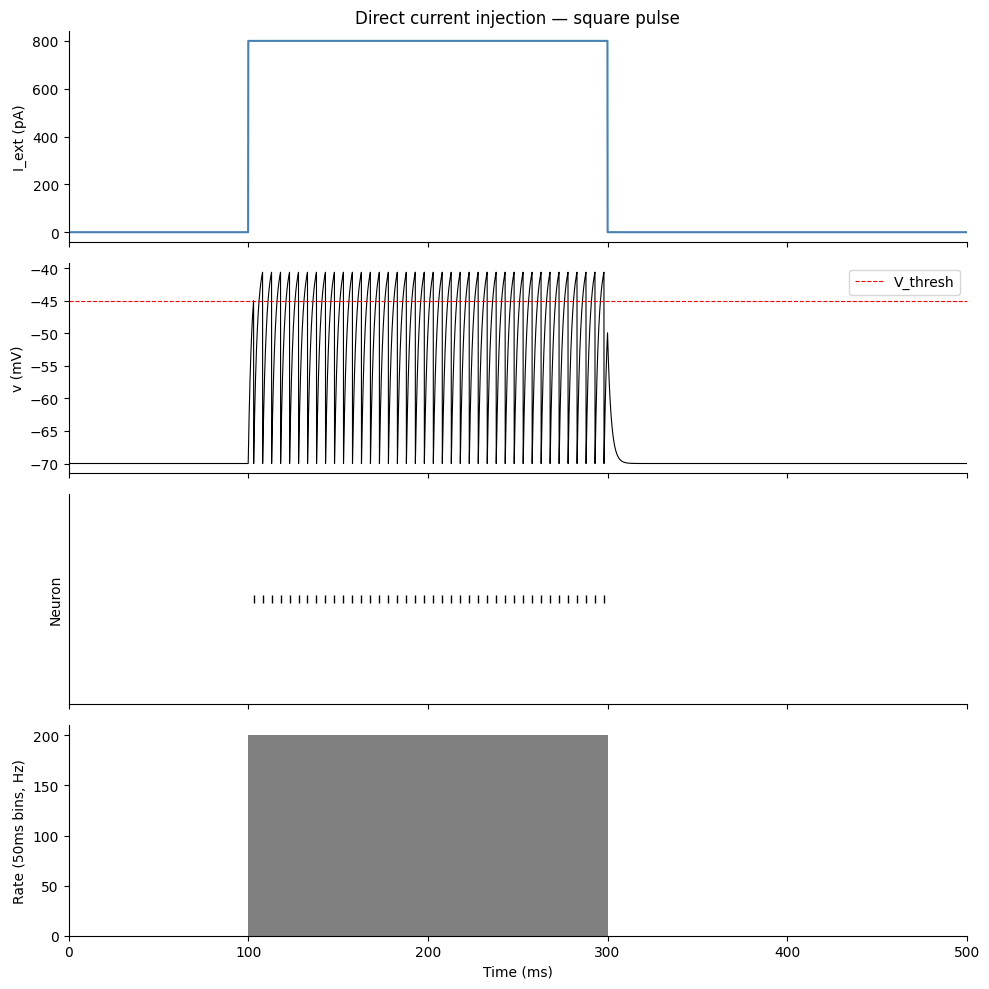

Mean firing rate during pulse: 200.0 Hz


In [282]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

# Stimulus
t_plot = np.arange(0, simulation_period/ms, b2.defaultclock.dt/ms)
stim_values = _pulse * I_amp
axes[0].plot(t_plot, stim_values / b2.pamp, color="steelblue")
axes[0].set_ylabel("I_ext (pA)")
axes[0].set_title("Direct current injection — square pulse")

# Voltage trace
axes[1].plot(state_monitor_I.t / ms, state_monitor_I.v[0] / mV, color="black", lw=0.8)
axes[1].axhline(V_thresh / mV, color="red", linestyle="--", lw=0.8, label="V_thresh")
axes[1].set_ylabel("v (mV)")
axes[1].legend(loc="upper right")

# Raster
axes[2].plot(spike_monitor_I.t / ms, spike_monitor_I.i, "k|", markersize=6)
axes[2].set_ylabel("Neuron")
axes[2].set_ylim(-0.5, n_neurons - 0.5)
axes[2].set_yticks([])

# Firing rate
rate, edges = np.histogram(spike_monitor_I.t / ms, bins=np.arange(0, simulation_period / ms + bin_size / ms, bin_size / ms))
axes[3].bar(edges[:-1], rate / (n_neurons * (bin_size / b2.second)), width=bin_size / ms, align="edge", color="gray")
axes[3].set_ylabel(f"Rate ({int(bin_size/ms)}ms bins, Hz)")
axes[3].set_xlabel("Time (ms)")
axes[3].set_xlim(0, simulation_period / ms)

plt.show()

print(f"Mean firing rate during pulse: {spike_monitor_I.num_spikes / n_neurons / (200*ms):.1f} Hz")

---
Add inputs to model

In [283]:
# Input waveform function generators
def square_pulse(t, start=100 * ms, duration=200 * ms):
    return 1.0 * (start <= t < start + duration)
def gaussian_pulse(t, center=200 * ms, width=50 * ms):
    return np.exp(-0.5 * ((t - center) / width) ** 2)

In [284]:
# Input waveform definition (plain numpy — TimedArray created inside each simulation cell)
simulation_period = 1000 * ms
t_array = np.arange(0, simulation_period/ms, b2.defaultclock.dt/ms) * ms

square_pulse_values = np.array([square_pulse(t, start=100*ms, duration=700*ms) for t in t_array])

---
Investigate response to square and Gaussian input to a realistic range of currents

In [285]:
b2.start_scope()
stim_array = b2.TimedArray(square_pulse_values, dt=b2.defaultclock.dt)
ng_sq = b2.NeuronGroup(n_neurons, lif_eqs, threshold="v > V_thresh", reset="v = V_reset", method="euler", refractory=refractory_period)
ng_sq.v = E_L
sm_sq = b2.SpikeMonitor(ng_sq)
stm_sq = b2.StateMonitor(ng_sq, ["v", "g_opsin"], record=0)
b2.run(simulation_period)

In [286]:
b2.start_scope()
gauss_values = np.array([gaussian_pulse(t, center=500*ms, width=150*ms) for t in t_array])
stim_array = b2.TimedArray(gauss_values, dt=b2.defaultclock.dt)
ng_gauss = b2.NeuronGroup(n_neurons, lif_eqs, threshold="v > V_thresh", reset="v = V_reset", method="euler", refractory=refractory_period)
ng_gauss.v = E_L
sm_gauss = b2.SpikeMonitor(ng_gauss)
stm_gauss = b2.StateMonitor(ng_gauss, ["v", "g_opsin"], record=0)
b2.run(simulation_period)

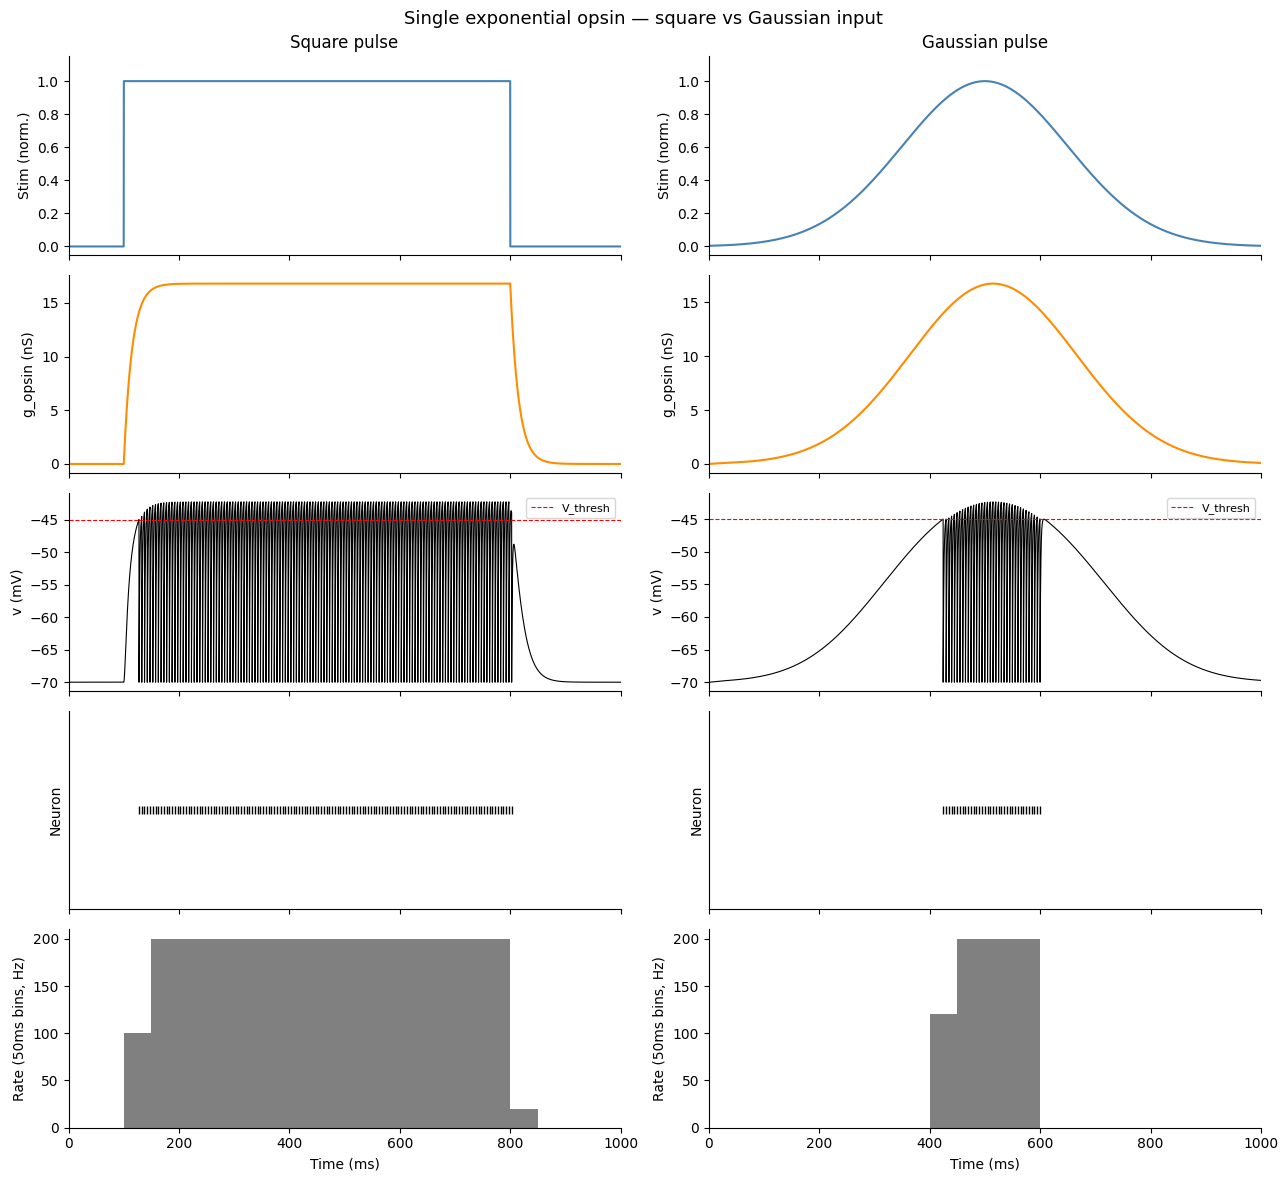

In [287]:
t_ms = stm_sq.t / ms
bins = np.arange(0, simulation_period/ms + bin_size/ms, bin_size/ms)

fig, axes = plt.subplots(5, 2, figsize=(13, 12), sharex=True)
fig.suptitle("Single exponential opsin — square vs Gaussian input", fontsize=13)

for col, (label, stim_vals, sm, stm) in enumerate([
    ("Square pulse", square_pulse_values, sm_sq, stm_sq),
    ("Gaussian pulse", gauss_values,      sm_gauss, stm_gauss),
]):
    axes[0, col].plot(t_ms, stim_vals, color="steelblue")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("Stim (norm.)")
    axes[0, col].set_ylim(-0.05, 1.15)

    axes[1, col].plot(stm.t / ms, stm.g_opsin[0] / nS, color="darkorange")
    axes[1, col].set_ylabel("g_opsin (nS)")

    axes[2, col].plot(stm.t / ms, stm.v[0] / mV, color="black", lw=0.8)
    axes[2, col].axhline(V_thresh / mV, color="red", ls="--", lw=0.8, label="V_thresh")
    axes[2, col].set_ylabel("v (mV)")
    axes[2, col].legend(loc="upper right", fontsize=8)

    axes[3, col].plot(sm.t / ms, sm.i, "k|", markersize=6)
    axes[3, col].set_ylabel("Neuron")
    axes[3, col].set_ylim(-0.5, n_neurons - 0.5)
    axes[3, col].set_yticks([])

    rate, edges = np.histogram(sm.t / ms, bins=bins)
    axes[4, col].bar(edges[:-1], rate / (n_neurons * (bin_size / b2.second)),
                     width=bin_size/ms, align="edge", color="gray")
    axes[4, col].set_ylabel(f"Rate ({int(bin_size/ms)}ms bins, Hz)")
    axes[4, col].set_xlabel("Time (ms)")

for ax in axes.flat:
    ax.set_xlim(0, simulation_period/ms)

plt.show()

## **Double exponential LIF model**

---
Define model

In [288]:
b2.prefs.codegen.target = "numpy"
b2.defaultclock.dt = 0.05 * ms
b2.seed(seed)

n_neurons = 1

# Membrane parameters (conductance-based LIF)
C_m = 500 * b2.pfarad
g_L = 25 * nS
E_L = -70 * mV
E_opsin = 0 * mV  # ChR2 reversal potential
V_reset = -70 * mV
V_thresh = -45 * mV

# Opsin parameters
w_opsin = 16.8 * nS   # Weight: max conductance at full expression
tau_rise = 10 * ms # 2.33 * ms  # Tune to get ~7 ms to peak
tau_decay = 2 * ms # 13.33 * ms  # Tune to get ~40 ms back to baseline

# Define LIF equations
lif_eqs = b2.Equations(
    """
    dv/dt       = (g_L*(E_L - v) + g_opsin*(E_opsin - v) + I_bg) / C_m : volt
    dg_opsin/dt = (h_opsin - g_opsin) / tau_decay                       : siemens
    dh_opsin/dt = (w_opsin * stim_array(t) - h_opsin) / tau_rise        : siemens
    I_bg        : amp
    """,
    C_m=C_m,
    g_L=g_L,
    E_L=E_L,
    E_opsin=E_opsin,
    w_opsin=w_opsin,
    tau_rise=tau_rise,
    tau_decay=tau_decay,
)

In [289]:
b2.start_scope()
stim_array = b2.TimedArray(square_pulse_values, dt=b2.defaultclock.dt)
ng_sq_2e = b2.NeuronGroup(n_neurons, lif_eqs, threshold="v > V_thresh", reset="v = V_reset", method="euler", refractory=refractory_period)
ng_sq_2e.v = E_L
sm_sq_2e = b2.SpikeMonitor(ng_sq_2e)
stm_sq_2e = b2.StateMonitor(ng_sq_2e, ["v", "g_opsin", "h_opsin"], record=0)
b2.run(simulation_period)

In [290]:
b2.start_scope()
stim_array = b2.TimedArray(gauss_values, dt=b2.defaultclock.dt)
ng_gauss_2e = b2.NeuronGroup(n_neurons, lif_eqs, threshold="v > V_thresh", reset="v = V_reset", method="euler", refractory=refractory_period)
ng_gauss_2e.v = E_L
sm_gauss_2e = b2.SpikeMonitor(ng_gauss_2e)
stm_gauss_2e = b2.StateMonitor(ng_gauss_2e, ["v", "g_opsin", "h_opsin"], record=0)
b2.run(simulation_period)

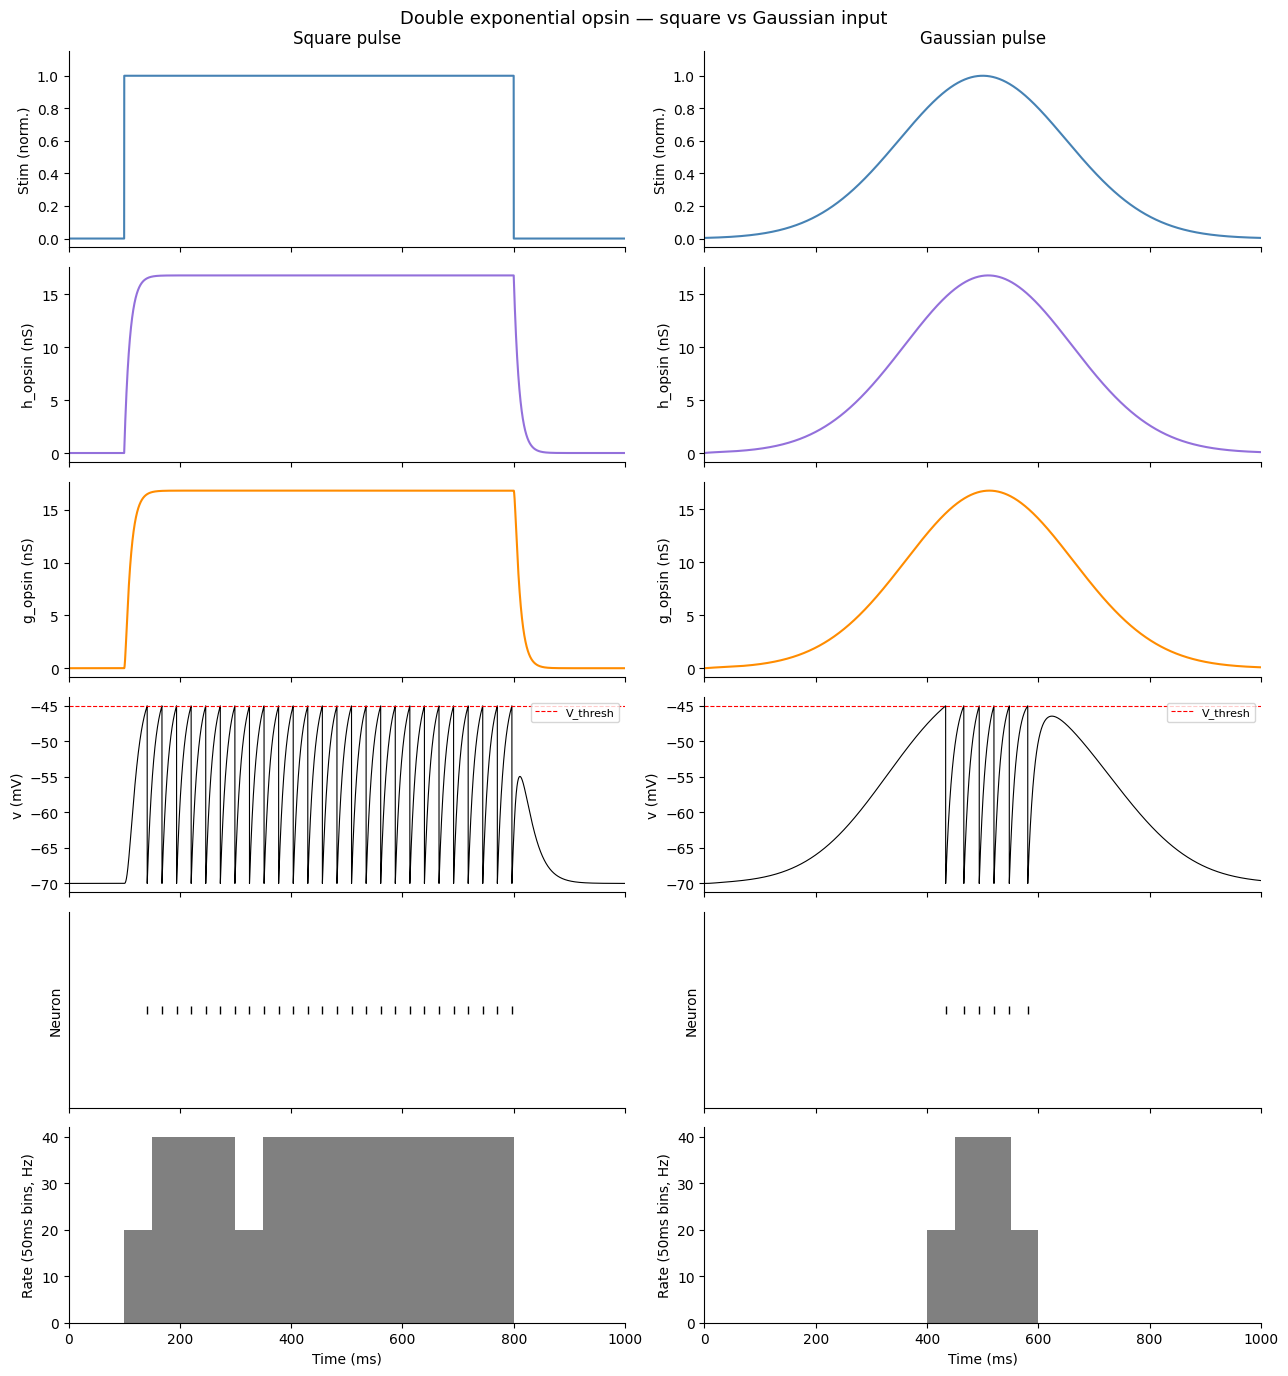

In [291]:
t_ms = stm_sq_2e.t / ms
bins = np.arange(0, simulation_period/ms + bin_size/ms, bin_size/ms)

fig, axes = plt.subplots(6, 2, figsize=(13, 14), sharex=True)
fig.suptitle("Double exponential opsin — square vs Gaussian input", fontsize=13)

for col, (label, stim_vals, sm, stm) in enumerate([
    ("Square pulse", square_pulse_values, sm_sq_2e,    stm_sq_2e),
    ("Gaussian pulse", gauss_values,      sm_gauss_2e, stm_gauss_2e),
]):
    axes[0, col].plot(t_ms, stim_vals, color="steelblue")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("Stim (norm.)")
    axes[0, col].set_ylim(-0.05, 1.15)

    axes[1, col].plot(stm.t / ms, stm.h_opsin[0] / nS, color="mediumpurple")
    axes[1, col].set_ylabel("h_opsin (nS)")

    axes[2, col].plot(stm.t / ms, stm.g_opsin[0] / nS, color="darkorange")
    axes[2, col].set_ylabel("g_opsin (nS)")

    axes[3, col].plot(stm.t / ms, stm.v[0] / mV, color="black", lw=0.8)
    axes[3, col].axhline(V_thresh / mV, color="red", ls="--", lw=0.8, label="V_thresh")
    axes[3, col].set_ylabel("v (mV)")
    axes[3, col].legend(loc="upper right", fontsize=8)

    axes[4, col].plot(sm.t / ms, sm.i, "k|", markersize=6)
    axes[4, col].set_ylabel("Neuron")
    axes[4, col].set_ylim(-0.5, n_neurons - 0.5)
    axes[4, col].set_yticks([])

    rate, edges = np.histogram(sm.t / ms, bins=bins)
    axes[5, col].bar(edges[:-1], rate / (n_neurons * (bin_size / b2.second)),
                     width=bin_size/ms, align="edge", color="gray")
    axes[5, col].set_ylabel(f"Rate ({int(bin_size/ms)}ms bins, Hz)")
    axes[5, col].set_xlabel("Time (ms)")

for ax in axes.flat:
    ax.set_xlim(0, simulation_period/ms)

plt.show()

## **Double exponential LIF model with desensitisation**

---
Define model

In [292]:
# Opsin parameters
w_opsin    = 16.8 * nS
tau_rise = 2.33 * ms  
tau_decay = 13.33 * ms
tau_sens   = 7000 * ms    # desensitisation rate during illumination
tau_recov  = 5000 * ms  # recovery rate in dark

lif_eqs = b2.Equations(
    """
    dv/dt       = (g_L*(E_L - v) + g_opsin*(E_opsin - v) + I_bg) / C_m : volt
    dg_opsin/dt = (h_opsin - g_opsin) / tau_decay                       : siemens
    dh_opsin/dt = (w_opsin * d * stim_array(t) - h_opsin) / tau_rise    : siemens
    dd/dt       = ((1 - d) / tau_recov) - (d * stim_array(t) / tau_sens): 1
    I_bg        : amp
    """,
    C_m=C_m,
    g_L=g_L,
    E_L=E_L,
    E_opsin=E_opsin,
    w_opsin=w_opsin,
    tau_rise=tau_rise,
    tau_decay=tau_decay,
    tau_sens=tau_sens,
    tau_recov=tau_recov,
)

In [293]:
b2.start_scope()
stim_array = b2.TimedArray(square_pulse_values, dt=b2.defaultclock.dt)
ng_sq_ds = b2.NeuronGroup(n_neurons, lif_eqs, threshold="v > V_thresh", reset="v = V_reset",
                           method="euler", refractory=refractory_period)
ng_sq_ds.v = E_L
ng_sq_ds.d = 1  # fully available at start
sm_sq_ds = b2.SpikeMonitor(ng_sq_ds)
stm_sq_ds = b2.StateMonitor(ng_sq_ds, ["v", "g_opsin", "h_opsin", "d"], record=0)
b2.run(simulation_period)

In [294]:
b2.start_scope()
stim_array = b2.TimedArray(gauss_values, dt=b2.defaultclock.dt)
ng_gauss_ds = b2.NeuronGroup(n_neurons, lif_eqs, threshold="v > V_thresh", reset="v = V_reset",
                              method="euler", refractory=refractory_period)
ng_gauss_ds.v = E_L
ng_gauss_ds.d = 1
sm_gauss_ds = b2.SpikeMonitor(ng_gauss_ds)
stm_gauss_ds = b2.StateMonitor(ng_gauss_ds, ["v", "g_opsin", "h_opsin", "d"], record=0)
b2.run(simulation_period)

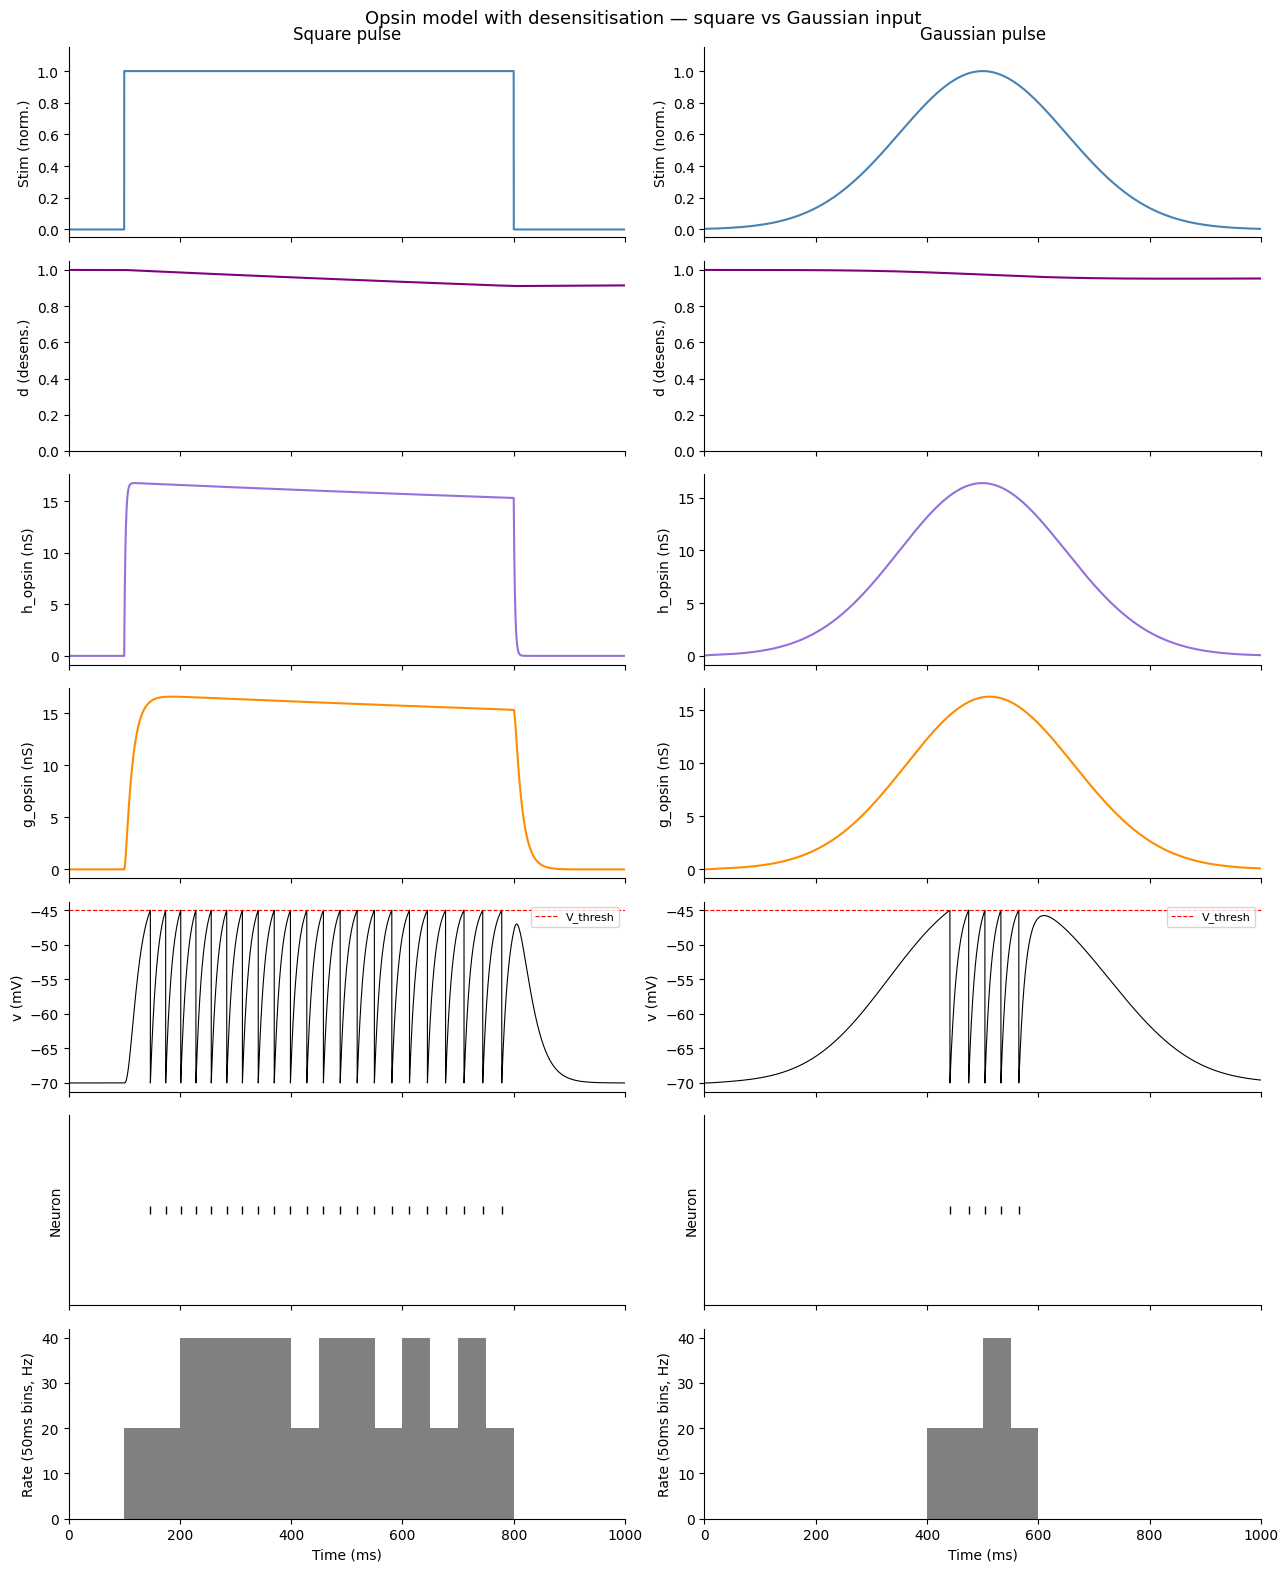

In [295]:
t_ms = stm_sq_ds.t / ms
bins = np.arange(0, simulation_period/ms + bin_size/ms, bin_size/ms)

fig, axes = plt.subplots(7, 2, figsize=(13, 16), sharex=True)
fig.suptitle("Opsin model with desensitisation — square vs Gaussian input", fontsize=13)

for col, (label, stim_vals, sm, stm) in enumerate([
    ("Square pulse",   square_pulse_values, sm_sq_ds,    stm_sq_ds),
    ("Gaussian pulse", gauss_values,        sm_gauss_ds, stm_gauss_ds),
]):
    axes[0, col].plot(t_ms, stim_vals, color="steelblue")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("Stim (norm.)")
    axes[0, col].set_ylim(-0.05, 1.15)

    axes[1, col].plot(stm.t / ms, stm.d[0], color="purple")
    axes[1, col].set_ylabel("d (desens.)")
    axes[1, col].set_ylim(0, 1.05)

    axes[2, col].plot(stm.t / ms, stm.h_opsin[0] / nS, color="mediumpurple")
    axes[2, col].set_ylabel("h_opsin (nS)")

    axes[3, col].plot(stm.t / ms, stm.g_opsin[0] / nS, color="darkorange")
    axes[3, col].set_ylabel("g_opsin (nS)")

    axes[4, col].plot(stm.t / ms, stm.v[0] / mV, color="black", lw=0.8)
    axes[4, col].axhline(V_thresh / mV, color="red", ls="--", lw=0.8, label="V_thresh")
    axes[4, col].set_ylabel("v (mV)")
    axes[4, col].legend(loc="upper right", fontsize=8)

    axes[5, col].plot(sm.t / ms, sm.i, "k|", markersize=6)
    axes[5, col].set_ylabel("Neuron")
    axes[5, col].set_ylim(-0.5, n_neurons - 0.5)
    axes[5, col].set_yticks([])

    rate, edges = np.histogram(sm.t / ms, bins=bins)
    axes[6, col].bar(edges[:-1], rate / (n_neurons * (bin_size / b2.second)),
                     width=bin_size/ms, align="edge", color="gray")
    axes[6, col].set_ylabel(f"Rate ({int(bin_size/ms)}ms bins, Hz)")
    axes[6, col].set_xlabel("Time (ms)")

for ax in axes.flat:
    ax.set_xlim(0, simulation_period/ms)

plt.show()

## **Normalised double exponential model**
---
Define model

In [296]:
w_opsin   = 16.8 * nS
tau_rise  = 2    * ms
tau_decay = 12   * ms

# Compute normalisation factor using plain floats (seconds) to avoid Brian2 quantity issues
_tr = float(tau_rise  / b2.second)
_td = float(tau_decay / b2.second)
_tp = (_tr * _td) / (_td - _tr) * np.log(_td / _tr)
factor = float(1.0 / (np.exp(-_tp / _td) - np.exp(-_tp / _tr)))

# s_decay and s_rise are dimensionless (driven by normalised stim),
# so g_opsin = w_opsin * factor * (s_decay - s_rise) has units of siemens.
lif_eqs_norm2e = b2.Equations(
    """
    dv/dt       = (g_L*(E_L - v) + g_opsin*(E_opsin - v) + I_bg) / C_m : volt
    g_opsin     = w_opsin * factor * (s_decay - s_rise)                 : siemens
    ds_decay/dt = (stim_array(t) - s_decay) / tau_decay                 : 1
    ds_rise/dt  = (stim_array(t) - s_rise)  / tau_rise                  : 1
    I_bg        : amp
    """,
    C_m=C_m, g_L=g_L, E_L=E_L, E_opsin=E_opsin,
    w_opsin=w_opsin, tau_rise=tau_rise, tau_decay=tau_decay, factor=factor,
)

print(f"tp = {_tp*1e3:.2f} ms  |  factor = {factor:.4f}")

tp = 4.30 ms  |  factor = 1.7172


In [297]:
b2.start_scope()
stim_array = b2.TimedArray(square_pulse_values, dt=b2.defaultclock.dt)
ng_sq_n2e = b2.NeuronGroup(n_neurons, lif_eqs_norm2e, threshold="v > V_thresh", reset="v = V_reset",
                            method="euler", refractory=refractory_period)
ng_sq_n2e.v = E_L
sm_sq_n2e  = b2.SpikeMonitor(ng_sq_n2e)
stm_sq_n2e = b2.StateMonitor(ng_sq_n2e, ["v", "g_opsin", "s_decay", "s_rise"], record=0)
b2.run(simulation_period)

In [298]:
b2.start_scope()
stim_array = b2.TimedArray(gauss_values, dt=b2.defaultclock.dt)
ng_gauss_n2e = b2.NeuronGroup(n_neurons, lif_eqs_norm2e, threshold="v > V_thresh", reset="v = V_reset",
                               method="euler", refractory=refractory_period)
ng_gauss_n2e.v = E_L
sm_gauss_n2e  = b2.SpikeMonitor(ng_gauss_n2e)
stm_gauss_n2e = b2.StateMonitor(ng_gauss_n2e, ["v", "g_opsin", "s_decay", "s_rise"], record=0)
b2.run(simulation_period)

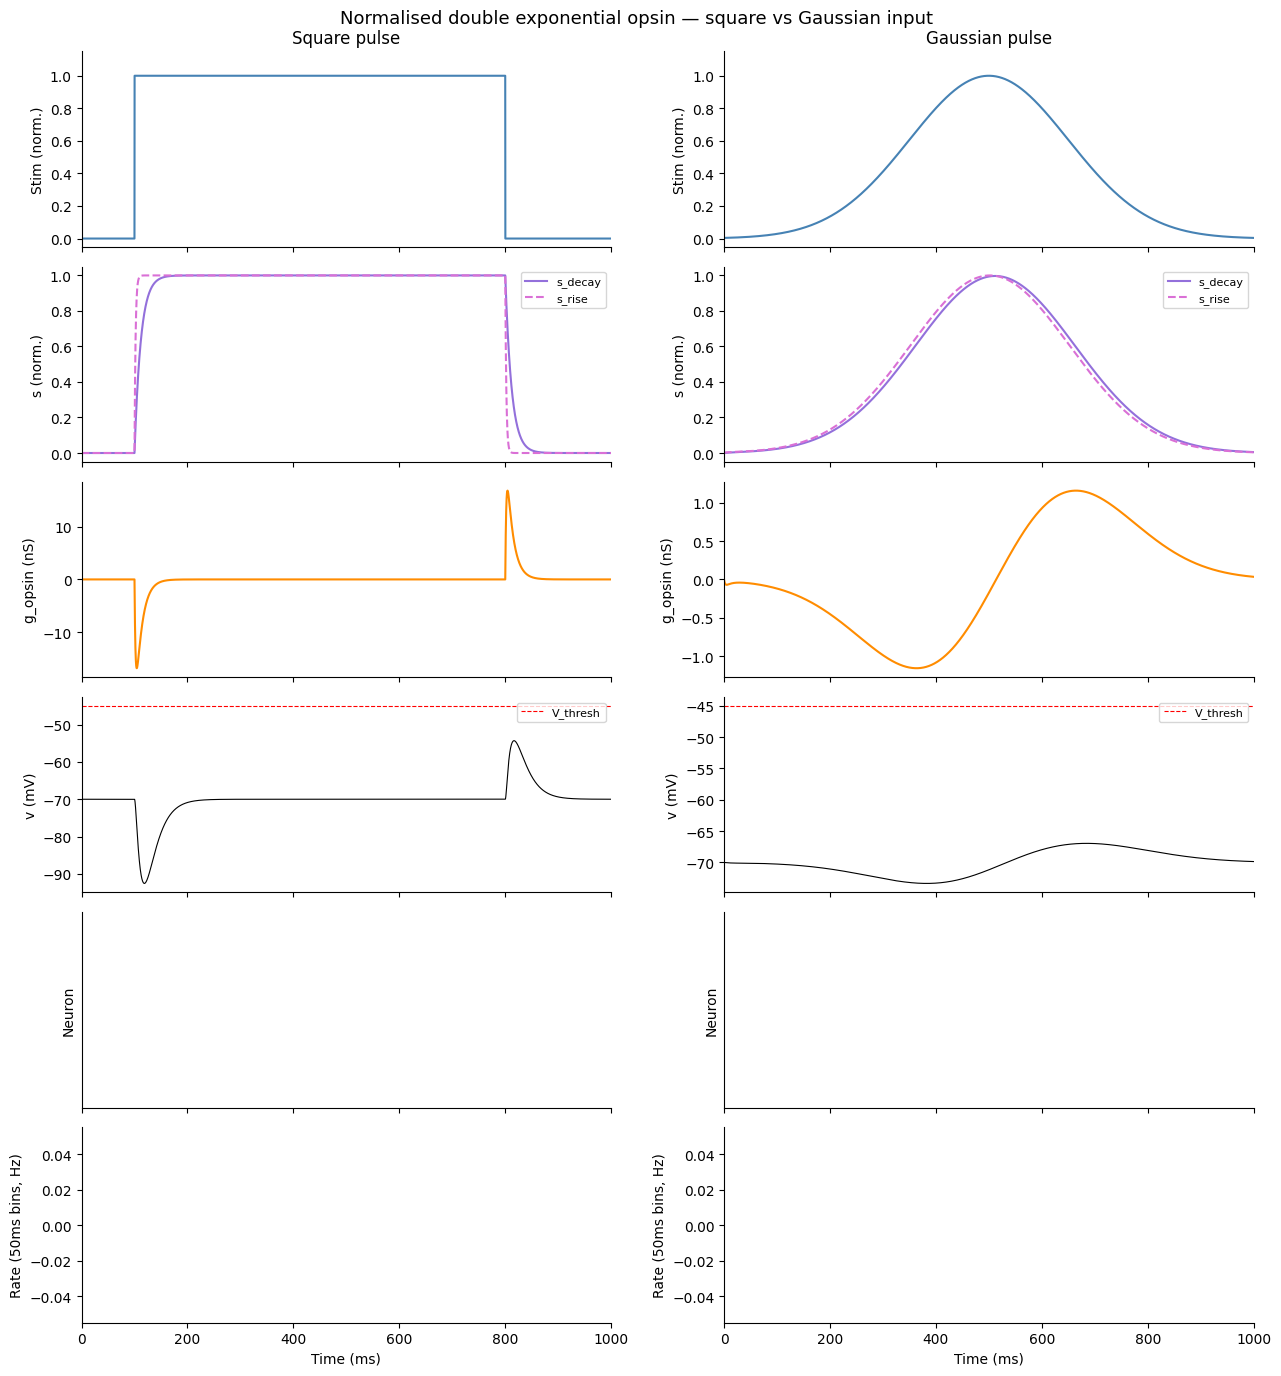

In [299]:
t_ms = stm_sq_n2e.t / ms
bins = np.arange(0, simulation_period/ms + bin_size/ms, bin_size/ms)

fig, axes = plt.subplots(6, 2, figsize=(13, 14), sharex=True)
fig.suptitle("Normalised double exponential opsin — square vs Gaussian input", fontsize=13)

for col, (label, stim_vals, sm, stm) in enumerate([
    ("Square pulse",   square_pulse_values, sm_sq_n2e,    stm_sq_n2e),
    ("Gaussian pulse", gauss_values,        sm_gauss_n2e, stm_gauss_n2e),
]):
    axes[0, col].plot(t_ms, stim_vals, color="steelblue")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("Stim (norm.)")
    axes[0, col].set_ylim(-0.05, 1.15)

    axes[1, col].plot(t_ms, stm.s_decay[0], color="mediumpurple", label="s_decay")
    axes[1, col].plot(t_ms, stm.s_rise[0],  color="orchid",       label="s_rise", ls="--")
    axes[1, col].set_ylabel("s (norm.)")
    axes[1, col].legend(loc="upper right", fontsize=8)

    axes[2, col].plot(stm.t / ms, stm.g_opsin[0] / nS, color="darkorange")
    axes[2, col].set_ylabel("g_opsin (nS)")

    axes[3, col].plot(stm.t / ms, stm.v[0] / mV, color="black", lw=0.8)
    axes[3, col].axhline(V_thresh / mV, color="red", ls="--", lw=0.8, label="V_thresh")
    axes[3, col].set_ylabel("v (mV)")
    axes[3, col].legend(loc="upper right", fontsize=8)

    axes[4, col].plot(sm.t / ms, sm.i, "k|", markersize=6)
    axes[4, col].set_ylabel("Neuron")
    axes[4, col].set_ylim(-0.5, n_neurons - 0.5)
    axes[4, col].set_yticks([])

    rate, edges = np.histogram(sm.t / ms, bins=bins)
    axes[5, col].bar(edges[:-1], rate / (n_neurons * (bin_size / b2.second)),
                     width=bin_size/ms, align="edge", color="gray")
    axes[5, col].set_ylabel(f"Rate ({int(bin_size/ms)}ms bins, Hz)")
    axes[5, col].set_xlabel("Time (ms)")

for ax in axes.flat:
    ax.set_xlim(0, simulation_period/ms)

plt.show()

## **Instantaneous rise model**
---
Define model

In [300]:
w_opsin   = 16.8 * nS
tau_decay = 12   * ms

lif_eqs_inst = b2.Equations(
    """
    dv/dt       = (g_L*(E_L - v) + g_opsin*(E_opsin - v) + I_bg) / C_m : volt
    dg_opsin/dt = -g_opsin / tau_decay                                   : siemens
    stim        : 1 (shared)
    I_bg        : amp
    """,
    C_m=C_m, g_L=g_L, E_L=E_L, E_opsin=E_opsin, tau_decay=tau_decay,
)

In [301]:
def run_inst_sim(stim_values):
    b2.start_scope()
    b2.defaultclock.dt = 0.05 * ms

    neuron = b2.NeuronGroup(
        n_neurons, lif_eqs_inst,
        threshold="v > V_thresh", reset="v = V_reset",
        method="euler", refractory=refractory_period,
    )
    neuron.v = E_L

    @b2.network_operation(when="start", dt=b2.defaultclock.dt)
    def update_stim():
        idx = int(round(float(b2.defaultclock.t / b2.defaultclock.dt)))
        idx = min(idx, len(stim_values) - 1)
        s = stim_values[idx]
        neuron.stim = s
        if s > 0:
            neuron.g_opsin = w_opsin * s   # instantaneous set each timestep

    sm  = b2.SpikeMonitor(neuron)
    stm = b2.StateMonitor(neuron, ["v", "g_opsin"], record=0)
    b2.run(len(stim_values) * b2.defaultclock.dt)
    return sm, stm

In [302]:
sm_sq_inst,    stm_sq_inst    = run_inst_sim(square_pulse_values)
sm_gauss_inst, stm_gauss_inst = run_inst_sim(gauss_values)

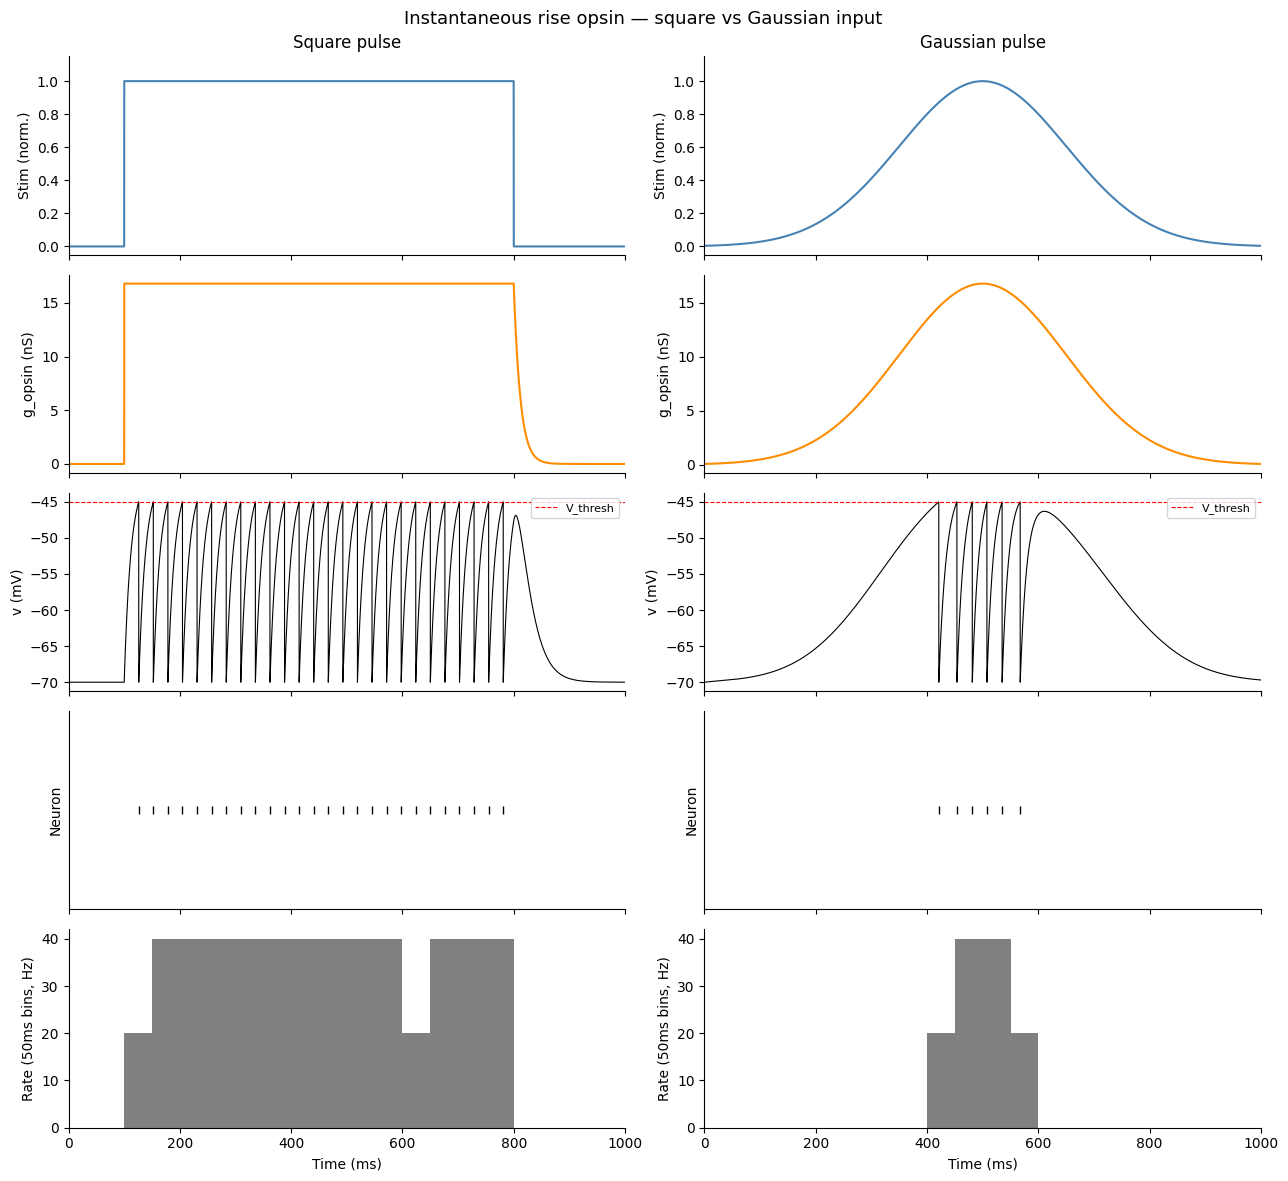

In [303]:
t_ms = stm_sq_inst.t / ms
bins = np.arange(0, simulation_period/ms + bin_size/ms, bin_size/ms)

fig, axes = plt.subplots(5, 2, figsize=(13, 12), sharex=True)
fig.suptitle("Instantaneous rise opsin — square vs Gaussian input", fontsize=13)

for col, (label, stim_vals, sm, stm) in enumerate([
    ("Square pulse",   square_pulse_values, sm_sq_inst,    stm_sq_inst),
    ("Gaussian pulse", gauss_values,        sm_gauss_inst, stm_gauss_inst),
]):
    axes[0, col].plot(t_ms, stim_vals, color="steelblue")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("Stim (norm.)")
    axes[0, col].set_ylim(-0.05, 1.15)

    axes[1, col].plot(stm.t / ms, stm.g_opsin[0] / nS, color="darkorange")
    axes[1, col].set_ylabel("g_opsin (nS)")

    axes[2, col].plot(stm.t / ms, stm.v[0] / mV, color="black", lw=0.8)
    axes[2, col].axhline(V_thresh / mV, color="red", ls="--", lw=0.8, label="V_thresh")
    axes[2, col].set_ylabel("v (mV)")
    axes[2, col].legend(loc="upper right", fontsize=8)

    axes[3, col].plot(sm.t / ms, sm.i, "k|", markersize=6)
    axes[3, col].set_ylabel("Neuron")
    axes[3, col].set_ylim(-0.5, n_neurons - 0.5)
    axes[3, col].set_yticks([])

    rate, edges = np.histogram(sm.t / ms, bins=bins)
    axes[4, col].bar(edges[:-1], rate / (n_neurons * (bin_size / b2.second)),
                     width=bin_size/ms, align="edge", color="gray")
    axes[4, col].set_ylabel(f"Rate ({int(bin_size/ms)}ms bins, Hz)")
    axes[4, col].set_xlabel("Time (ms)")

for ax in axes.flat:
    ax.set_xlim(0, simulation_period/ms)

plt.show()

## **Instantaneous rise model with desensitisation**
---
Define model

In [304]:
w_opsin   = 20.0 * nS   # increased from 16.8: with d_inf=0.8, need w > 17.4 nS to sustain V > V_thresh
tau_decay = 12   * ms
tau_deact = 20   * ms   # desensitisation time constant (drop to plateau)
tau_recov = 200  * ms   # recovery time constant (between pulses)
d_inf     = 0.8         # steady-state desensitisation (80% of peak)

# Sanity check: V_ss at d=d_inf (should be > V_thresh for sustained firing)
_V_ss = float(g_L * E_L / (g_L + w_opsin * d_inf) / mV)
print(f"V_ss at d=d_inf: {_V_ss:.1f} mV  (V_thresh = {float(V_thresh/mV):.1f} mV)")

lif_eqs_inst_ds = b2.Equations(
    """
    dv/dt       = (g_L*(E_L - v) + g_opsin * d * (E_opsin - v) + I_bg) / C_m : volt
    dg_opsin/dt = -g_opsin / tau_decay                                         : siemens
    dd/dt       = stim * (d_inf - d) / tau_deact + (1 - stim) * (1.0 - d) / tau_recov : 1
    stim        : 1 (shared)
    I_bg        : amp
    """,
    C_m=C_m, g_L=g_L, E_L=E_L, E_opsin=E_opsin,
    tau_decay=tau_decay, tau_deact=tau_deact, tau_recov=tau_recov, d_inf=d_inf,
)

V_ss at d=d_inf: -42.7 mV  (V_thresh = -45.0 mV)


In [305]:
def run_inst_ds_sim(stim_values):
    b2.start_scope()
    b2.defaultclock.dt = 0.05 * ms

    neuron = b2.NeuronGroup(
        n_neurons, lif_eqs_inst_ds,
        threshold="v > V_thresh", reset="v = V_reset",
        method="euler", refractory=refractory_period,
    )
    neuron.v    = E_L
    neuron.d    = 1.0   # fully available at start
    neuron.stim = 0.0

    @b2.network_operation(when="start", dt=b2.defaultclock.dt)
    def update_stim():
        idx = int(round(float(b2.defaultclock.t / b2.defaultclock.dt)))
        idx = min(idx, len(stim_values) - 1)
        s = stim_values[idx]
        neuron.stim = s
        if s > 0:
            neuron.g_opsin = w_opsin * s   # instantaneous set each timestep

    sm  = b2.SpikeMonitor(neuron)
    stm = b2.StateMonitor(neuron, ["v", "g_opsin", "d"], record=0)
    b2.run(len(stim_values) * b2.defaultclock.dt)
    return sm, stm

In [306]:
sm_sq_ids,    stm_sq_ids    = run_inst_ds_sim(square_pulse_values)
sm_gauss_ids, stm_gauss_ids = run_inst_ds_sim(gauss_values)

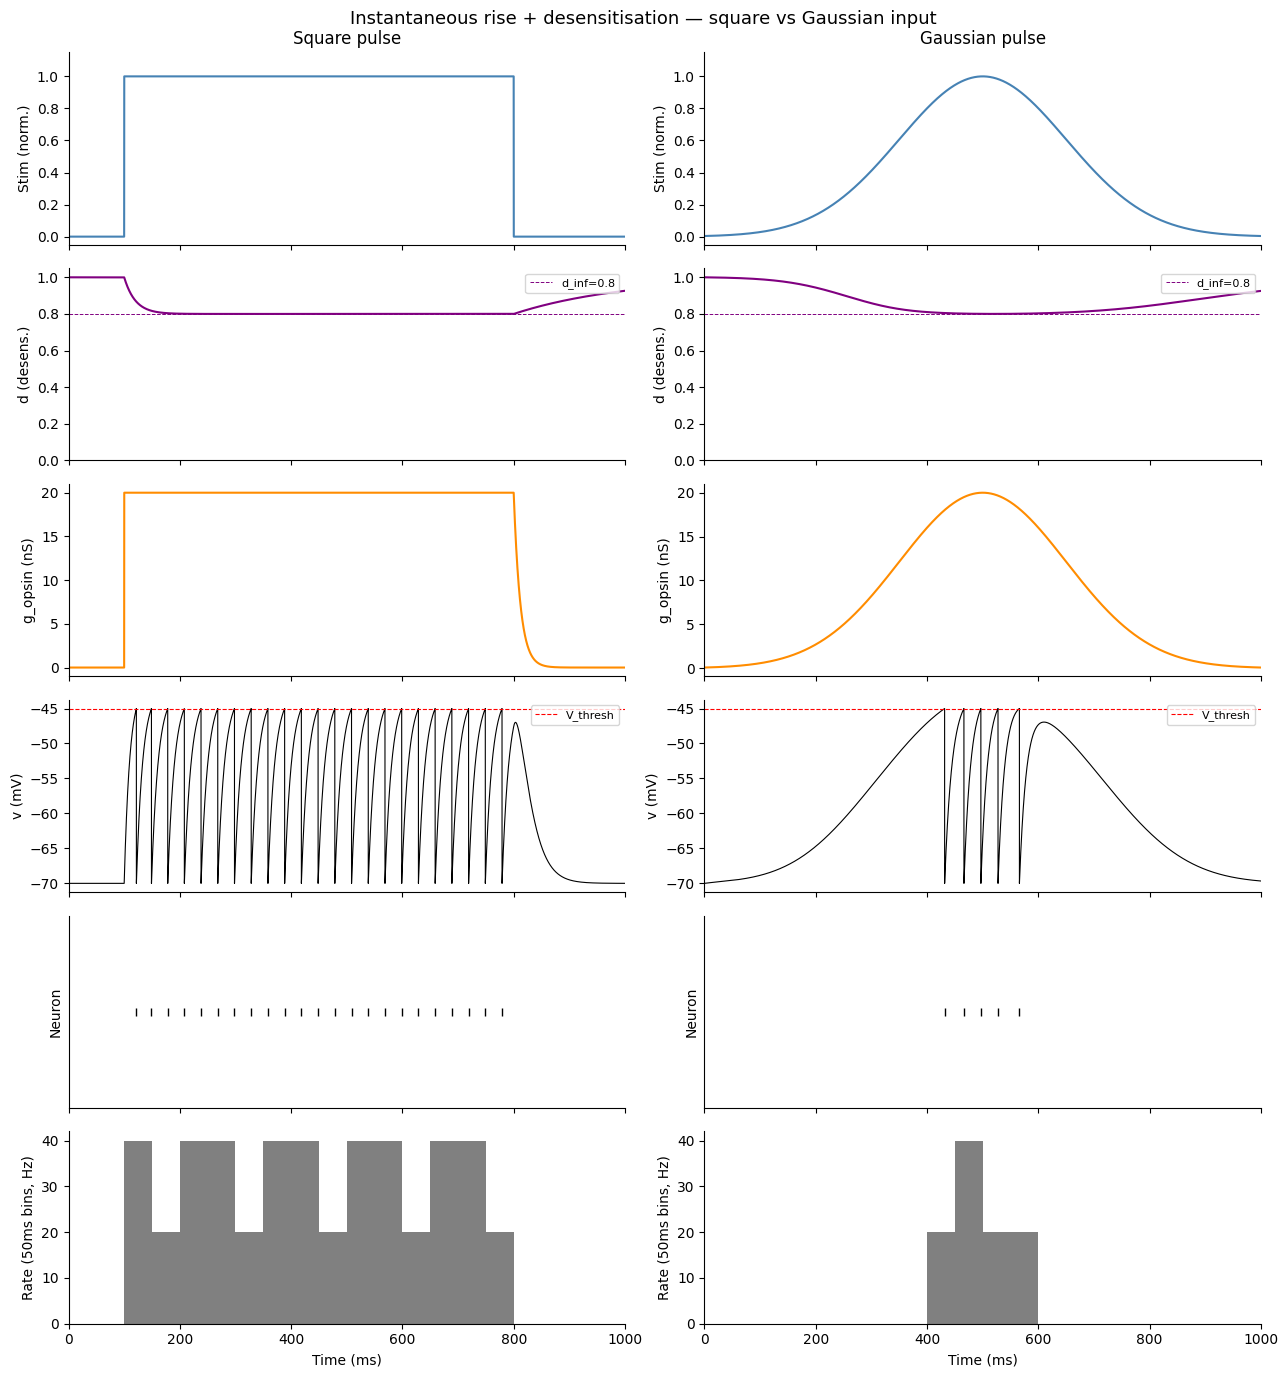

In [307]:
t_ms = stm_sq_ids.t / ms
bins = np.arange(0, simulation_period/ms + bin_size/ms, bin_size/ms)

fig, axes = plt.subplots(6, 2, figsize=(13, 14), sharex=True)
fig.suptitle("Instantaneous rise + desensitisation — square vs Gaussian input", fontsize=13)

for col, (label, stim_vals, sm, stm) in enumerate([
    ("Square pulse",   square_pulse_values, sm_sq_ids,    stm_sq_ids),
    ("Gaussian pulse", gauss_values,        sm_gauss_ids, stm_gauss_ids),
]):
    axes[0, col].plot(t_ms, stim_vals, color="steelblue")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("Stim (norm.)")
    axes[0, col].set_ylim(-0.05, 1.15)

    axes[1, col].plot(stm.t / ms, stm.d[0], color="purple")
    axes[1, col].set_ylabel("d (desens.)")
    axes[1, col].axhline(d_inf, color="purple", ls="--", lw=0.7, label=f"d_inf={d_inf}")
    axes[1, col].set_ylim(0, 1.05)
    axes[1, col].legend(loc="upper right", fontsize=8)

    axes[2, col].plot(stm.t / ms, stm.g_opsin[0] / nS, color="darkorange")
    axes[2, col].set_ylabel("g_opsin (nS)")

    axes[3, col].plot(stm.t / ms, stm.v[0] / mV, color="black", lw=0.8)
    axes[3, col].axhline(V_thresh / mV, color="red", ls="--", lw=0.8, label="V_thresh")
    axes[3, col].set_ylabel("v (mV)")
    axes[3, col].legend(loc="upper right", fontsize=8)

    axes[4, col].plot(sm.t / ms, sm.i, "k|", markersize=6)
    axes[4, col].set_ylabel("Neuron")
    axes[4, col].set_ylim(-0.5, n_neurons - 0.5)
    axes[4, col].set_yticks([])

    rate, edges = np.histogram(sm.t / ms, bins=bins)
    axes[5, col].bar(edges[:-1], rate / (n_neurons * (bin_size / b2.second)),
                     width=bin_size/ms, align="edge", color="gray")
    axes[5, col].set_ylabel(f"Rate ({int(bin_size/ms)}ms bins, Hz)")
    axes[5, col].set_xlabel("Time (ms)")

for ax in axes.flat:
    ax.set_xlim(0, simulation_period/ms)

plt.show()